## Explainability

In [1]:
import shap
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from tensorflow.keras.models import load_model
import os
import pandas as pd

/home/sssspppuud/Desktop/Project/Code/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-03-14 00:19:57.178198: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-14 00:19:57.221472: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-14 00:19:58.896577: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may se

In [2]:
PROJECT_ROOT = os.path.abspath("..")
DATA_DIR = os.path.join(PROJECT_ROOT, "data")
MODEL_DIR = os.path.join(PROJECT_ROOT, "models")
ARTIFACT_DIR = os.path.join(PROJECT_ROOT, "artifacts")

In [3]:
model = load_model(os.path.join(MODEL_DIR, "model.keras"))
X_test_scaled = np.load(os.path.join(ARTIFACT_DIR,"X_test.npy"))
y_test = np.load(os.path.join(ARTIFACT_DIR,"y_test.npy"))
encoder = joblib.load(os.path.join(ARTIFACT_DIR,"encoder.pkl"))
feature_names = joblib.load(os.path.join(ARTIFACT_DIR,"feature_names.pkl"))
background = np.load(os.path.join(ARTIFACT_DIR,"shap_background.npy"))

2026-03-14 00:19:59.170214: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


### SHAP

In [4]:
sample_size = 400
idx = np.random.choice(len(X_test_scaled), sample_size, replace = False)
X_sample = X_test_scaled[idx]
X_sample.shape

(400, 45)

In [5]:
explainer = shap.Explainer(model, background)
shap_values = explainer(X_sample)

PermutationExplainer explainer: 401it [01:40,  3.75it/s]                         


In [6]:
print(f"Model output shape: {model.output_shape}")
print(f"Number of SHAP arrays: {len(shap_values)}")
print(f"Number of labels: {len(encoder.classes_)}")

Model output shape: (None, 5)
Number of SHAP arrays: 400
Number of labels: 5


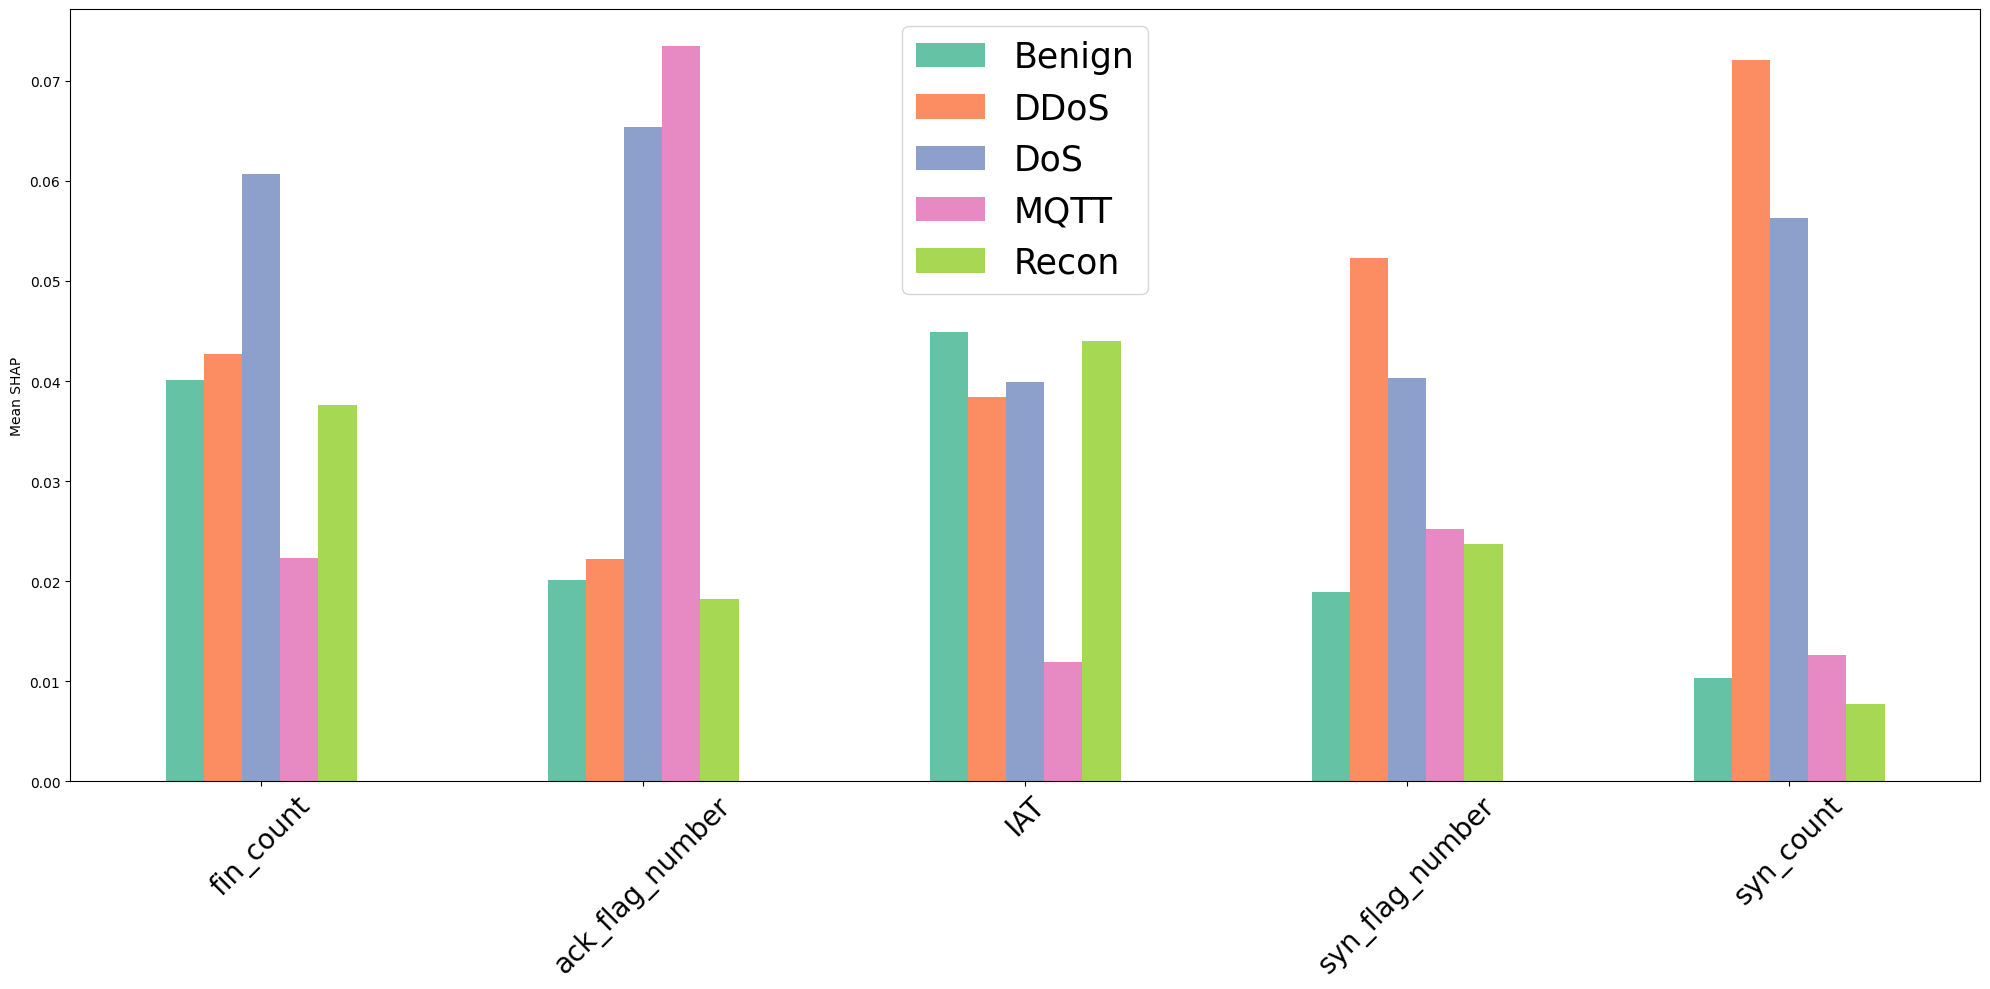

In [7]:
temp = pd.DataFrame()
temp.index = feature_names

for i, class_label in enumerate(encoder.classes_):
    mean = np.mean(np.abs(shap_values.values[:, :, i]), axis = 0)
    temp[class_label] = mean

top_features = temp.sum(axis=1).nlargest(5).index
temp_top = temp.loc[top_features]


fig,ax = plt.subplots(1,1, figsize = (20,10))
palette = sns.color_palette("Set2", n_colors=len(temp_top.columns))
temp_top.plot.bar(ax = ax, color = palette)
ax.set_ylabel("Mean SHAP")
ax.set_xticklabels(top_features, rotation=45, size = 20)
ax.legend(fontsize = 25)
plt.tight_layout()

/tmp/ipykernel_434817/4208562180.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


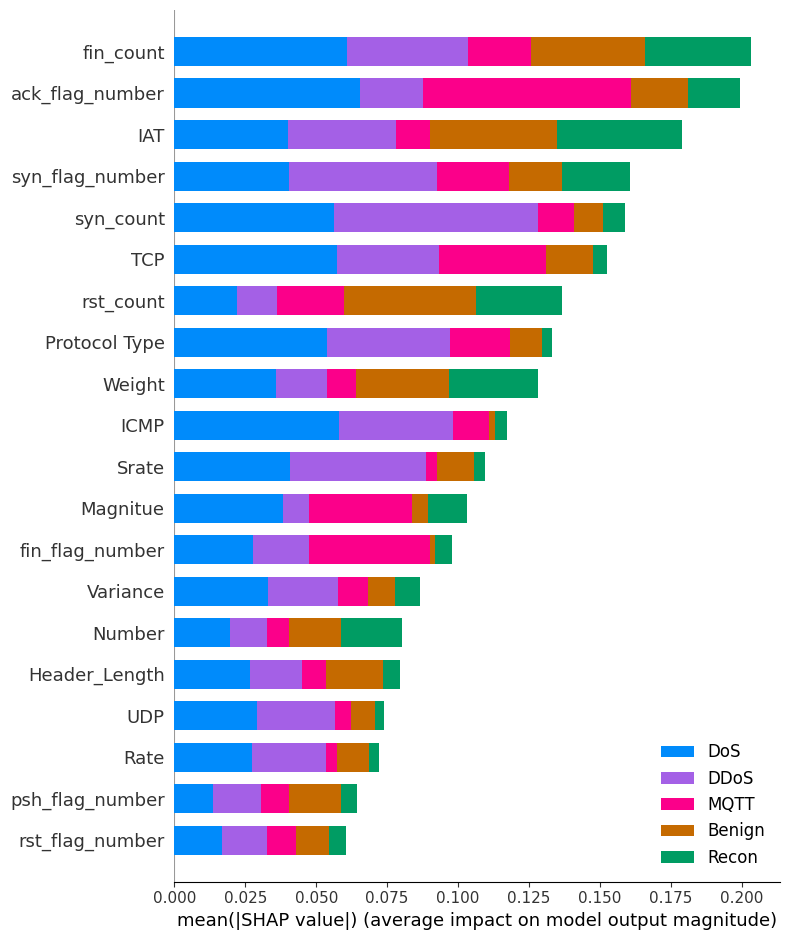

In [8]:
shap.summary_plot(
    shap_values,
    X_sample,
    feature_names = feature_names,
    plot_type="bar",
    class_names = encoder.classes_
)

/tmp/ipykernel_434817/1029745718.py:3: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


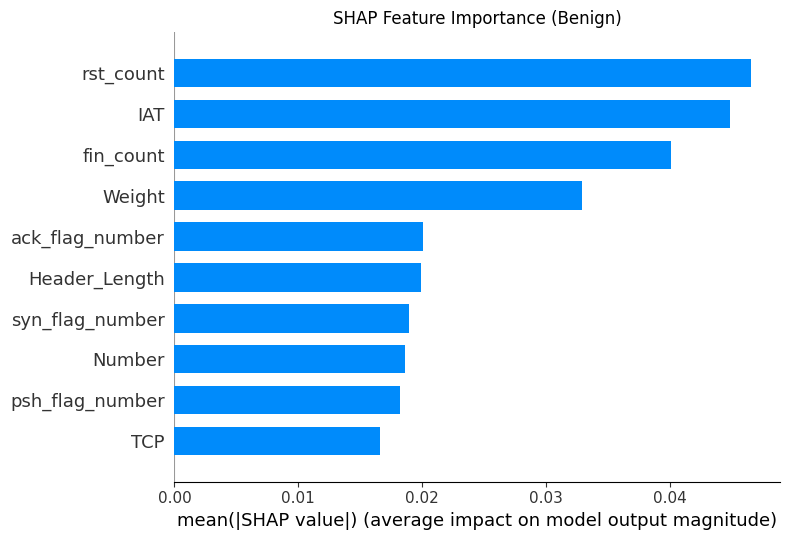

/tmp/ipykernel_434817/1029745718.py:3: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


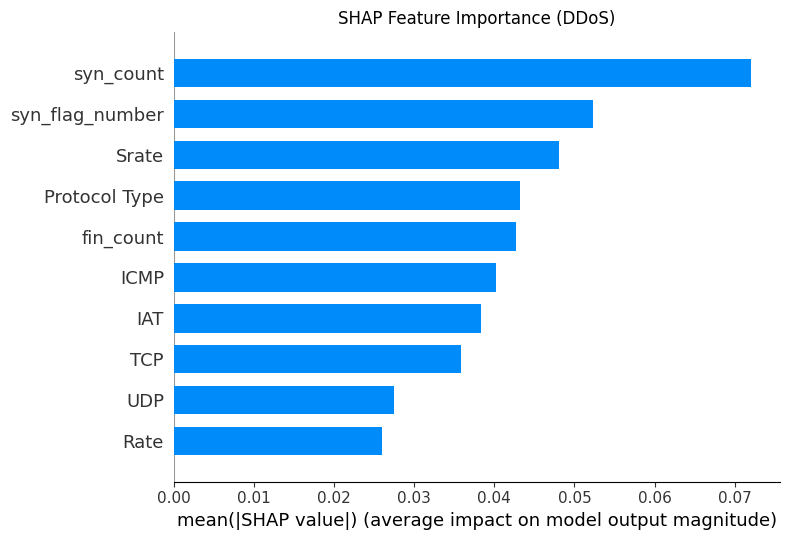

/tmp/ipykernel_434817/1029745718.py:3: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


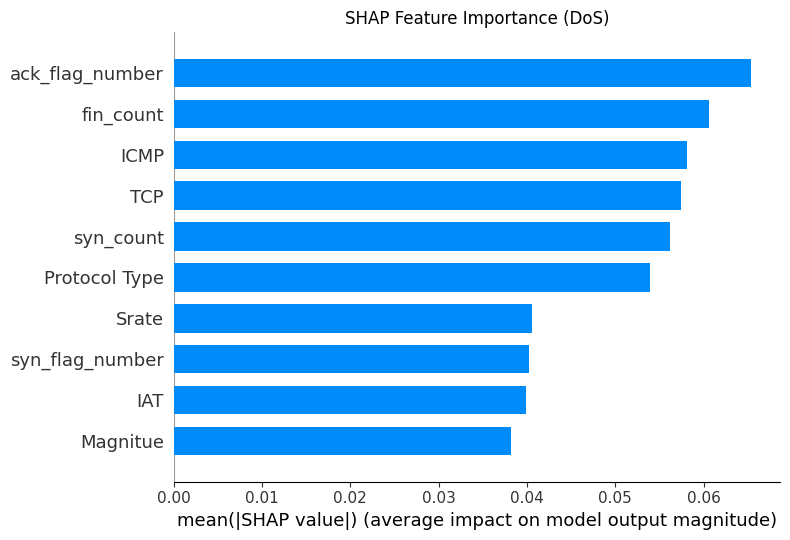

/tmp/ipykernel_434817/1029745718.py:3: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


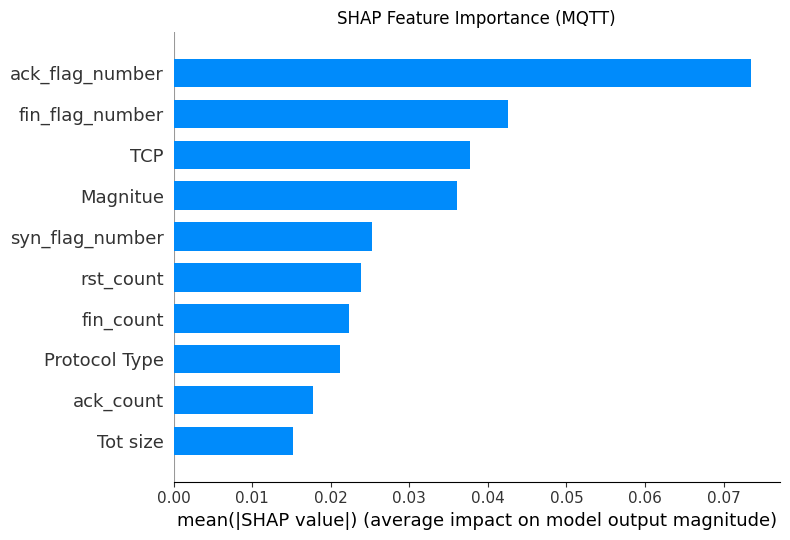

/tmp/ipykernel_434817/1029745718.py:3: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


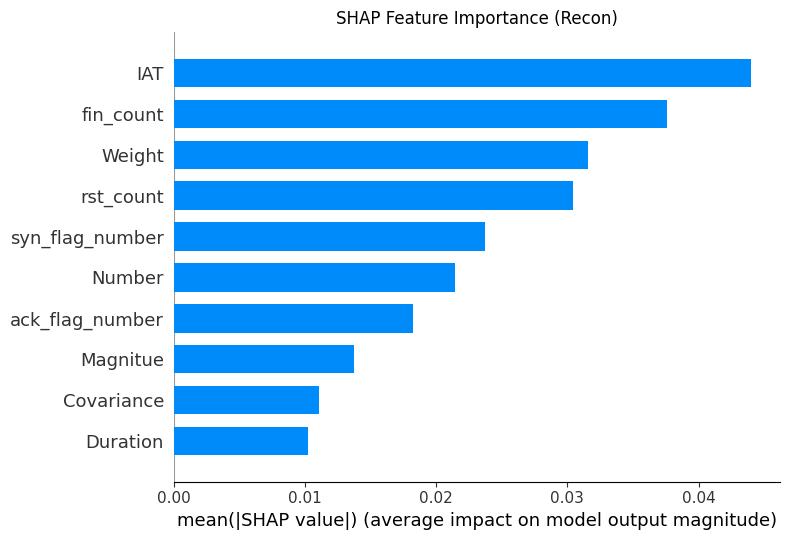

In [10]:
for i, class_label in enumerate(encoder.classes_):
    plt.title(f"SHAP Feature Importance ({class_label})")
    shap.summary_plot(
        shap_values[..., i],
        X_sample,
        feature_names = feature_names,
        plot_type = "bar",
        show = True,
        max_display = 10
    )


/tmp/ipykernel_434817/3350446522.py:3: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


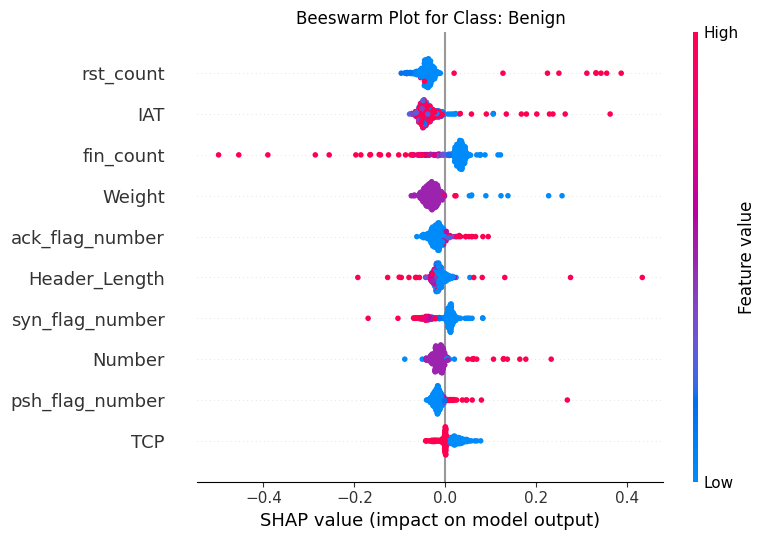

/tmp/ipykernel_434817/3350446522.py:3: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


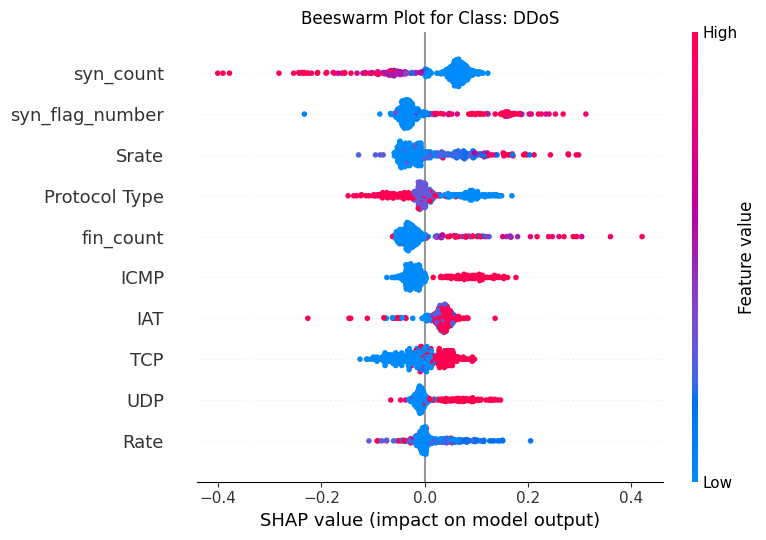

/tmp/ipykernel_434817/3350446522.py:3: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


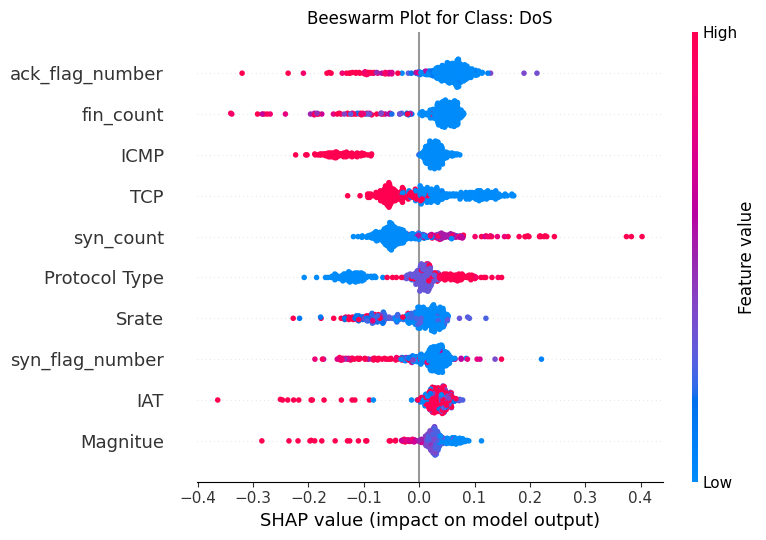

/tmp/ipykernel_434817/3350446522.py:3: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


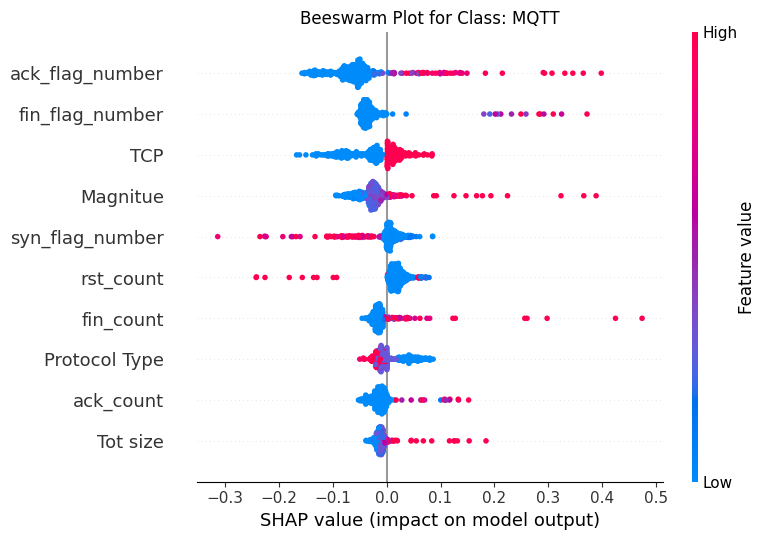

/tmp/ipykernel_434817/3350446522.py:3: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


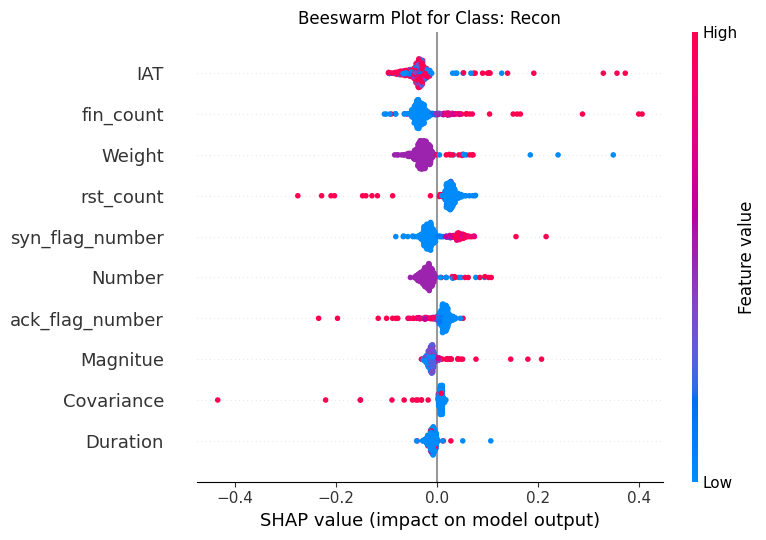

In [11]:
for i, class_label in enumerate(encoder.classes_):
    plt.title(f"Beeswarm Plot for Class: {class_label}")
    shap.summary_plot(
        shap_values[..., i],
        X_sample,
        feature_names=feature_names,
        max_display = 10
    )

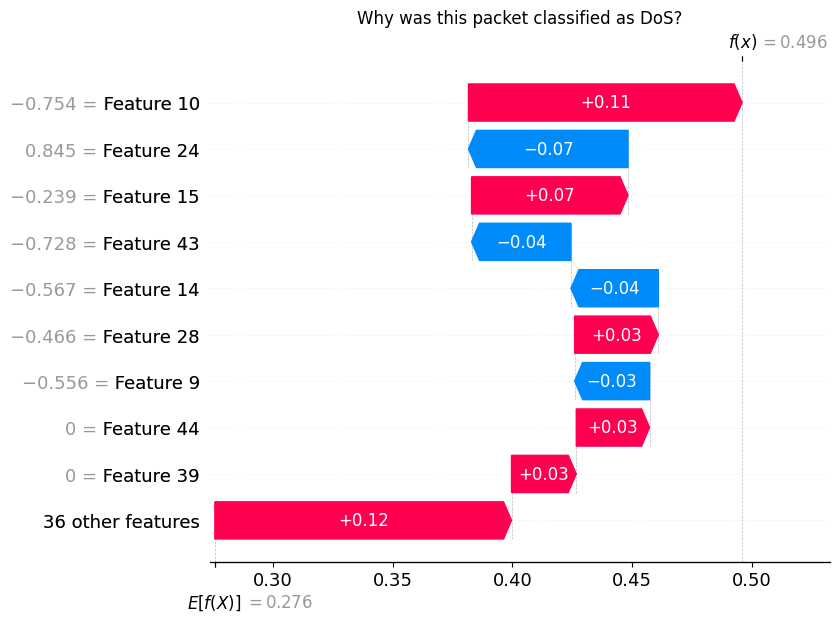

In [12]:
sample_idx = 0
class_to_explain = 2
plt.title(f"Why was this packet classified as {encoder.classes_[class_to_explain]}?")
shap.plots.waterfall(shap_values[sample_idx, :, class_to_explain], max_display=10)

In [13]:
shap.initjs()
shap.plots.force(
shap_values[sample_idx, :, class_to_explain],
matplotlib=False)